In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy.engine import URL
from sqlalchemy import create_engine

# ─── CONNECTION ──────────────────────────────────────────────
connection_url = URL.create(
    drivername="postgresql",
    username="postgres",
    password="Infi@2k4",
    host="localhost",
    port=5432,
    database="fifa_analytics"
)
engine = create_engine(connection_url)

# ─── LOAD TABLES ─────────────────────────────────────────────
matches    = pd.read_sql("SELECT * FROM fact_matches", engine)
tournament = pd.read_sql("SELECT * FROM dim_tournament", engine)
teams      = pd.read_sql("SELECT * FROM dim_team", engine)
rankings   = pd.read_sql("SELECT * FROM dim_rankings", engine)

print("Tables loaded successfully")
print(f"Matches: {matches.shape}")
print(f"Tournaments: {tournament.shape}")
print(f"Teams: {teams.shape}")
print(f"Rankings: {rankings.shape}")

Tables loaded successfully
Matches: (964, 22)
Tournaments: (22, 9)
Teams: (86, 4)
Rankings: (422, 8)


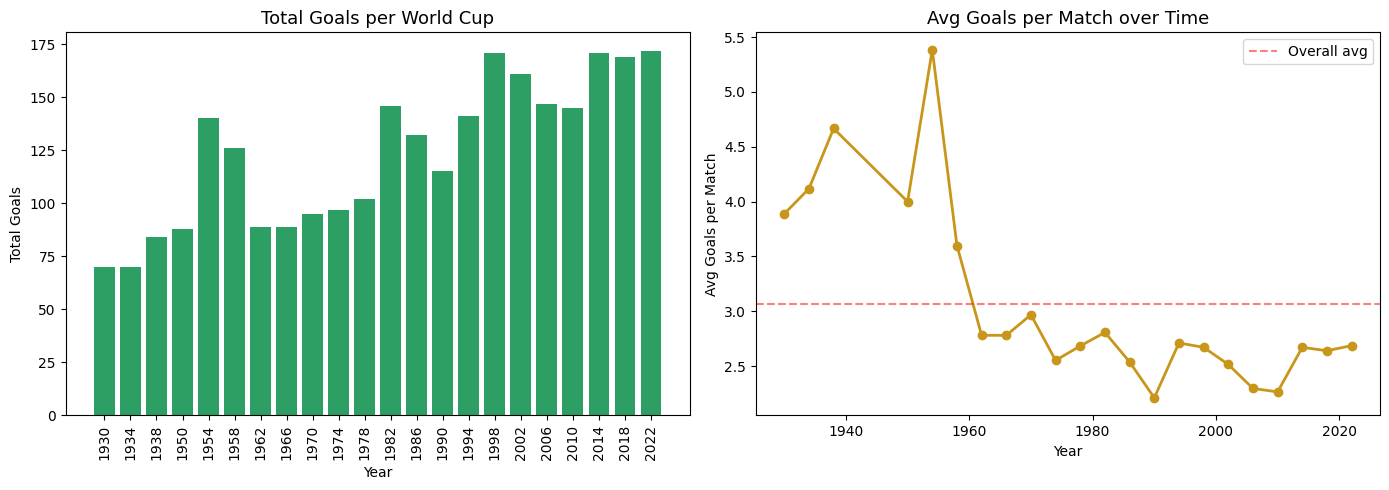

Overall avg goals per match: 3.07


In [2]:
# Tournament goal trends over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total goals per tournament
tournament_sorted = tournament.sort_values('year')
axes[0].bar(tournament_sorted['year'].astype(str), 
            tournament_sorted['total_matches'] * 0 + tournament_sorted['year'] * 0,
            color='#2d9e64')

# Use matches data for accurate goal totals
goals_per_year = matches.groupby('year')['total_goals'].sum().reset_index()
axes[0].bar(goals_per_year['year'].astype(str), goals_per_year['total_goals'], color='#2d9e64')
axes[0].set_title('Total Goals per World Cup', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Goals')
axes[0].tick_params(axis='x', rotation=90)

# Average goals per match per tournament
avg_goals = matches.groupby('year')['total_goals'].mean().reset_index()
axes[1].plot(avg_goals['year'], avg_goals['total_goals'], 
             marker='o', color='#c8961a', linewidth=2)
axes[1].set_title('Avg Goals per Match over Time', fontsize=13)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Goals per Match')
axes[1].axhline(y=avg_goals['total_goals'].mean(), 
                color='red', linestyle='--', alpha=0.5, label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/goal_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Overall avg goals per match: {avg_goals['total_goals'].mean():.2f}")

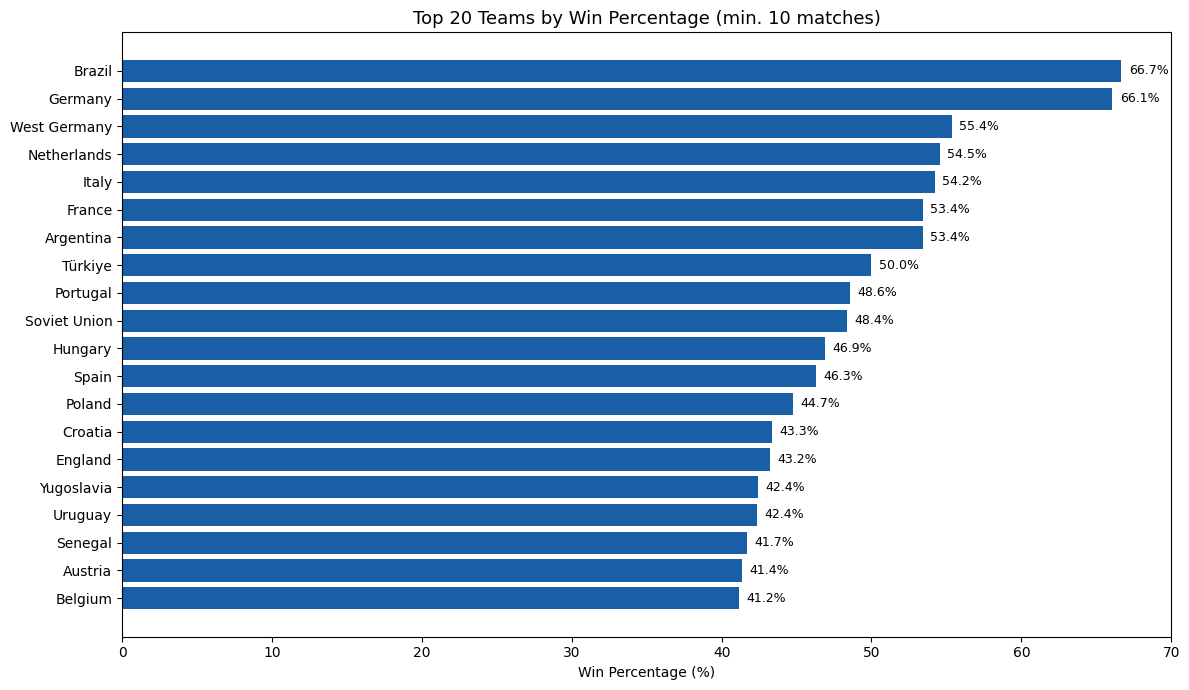


Top 10 Teams by Win %:
        team  played  wins  draws  losses   win_pct
      Brazil     114    76     19      19 66.666667
     Germany      56    37      7      12 66.071429
West Germany      56    31     14      11 55.357143
 Netherlands      55    30     14      11 54.545455
       Italy      83    45     21      17 54.216867
      France      73    39     14      20 53.424658
   Argentina      88    47     17      24 53.409091
     Türkiye      10     5      1       4 50.000000
    Portugal      35    17      6      12 48.571429
Soviet Union      31    15      6      10 48.387097


In [3]:
#Win rate by team (top 20)
# Calculate wins for home and away
home_wins = matches[matches['result'] == 'home_win'].groupby('home_team').size()
away_wins = matches[matches['result'] == 'away_win'].groupby('away_team').size()
draws_home = matches[matches['result'] == 'draw'].groupby('home_team').size()
draws_away = matches[matches['result'] == 'draw'].groupby('away_team').size()

# Total matches per team
home_matches = matches.groupby('home_team').size()
away_matches = matches.groupby('away_team').size()

# Combine
all_teams_list = set(matches['home_team'].unique()) | set(matches['away_team'].unique())
team_stats = []

for team in all_teams_list:
    wins   = home_wins.get(team, 0) + away_wins.get(team, 0)
    draws  = draws_home.get(team, 0) + draws_away.get(team, 0)
    played = home_matches.get(team, 0) + away_matches.get(team, 0)
    losses = played - wins - draws
    win_pct = (wins / played * 100) if played > 0 else 0
    team_stats.append({
        'team': team, 'played': played, 'wins': wins,
        'draws': draws, 'losses': losses, 'win_pct': win_pct
    })

team_df = pd.DataFrame(team_stats).sort_values('win_pct', ascending=False)
team_df = team_df[team_df['played'] >= 10]  # min 10 matches for fairness

# Plot top 20
top20 = team_df.head(20)
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20['team'], top20['win_pct'], color='#185fa5')
ax.set_xlabel('Win Percentage (%)')
ax.set_title('Top 20 Teams by Win Percentage (min. 10 matches)', fontsize=13)
ax.invert_yaxis()
for bar, val in zip(bars, top20['win_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/win_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Teams by Win %:")
print(team_df.head(10)[['team','played','wins','draws','losses','win_pct']].to_string(index=False))

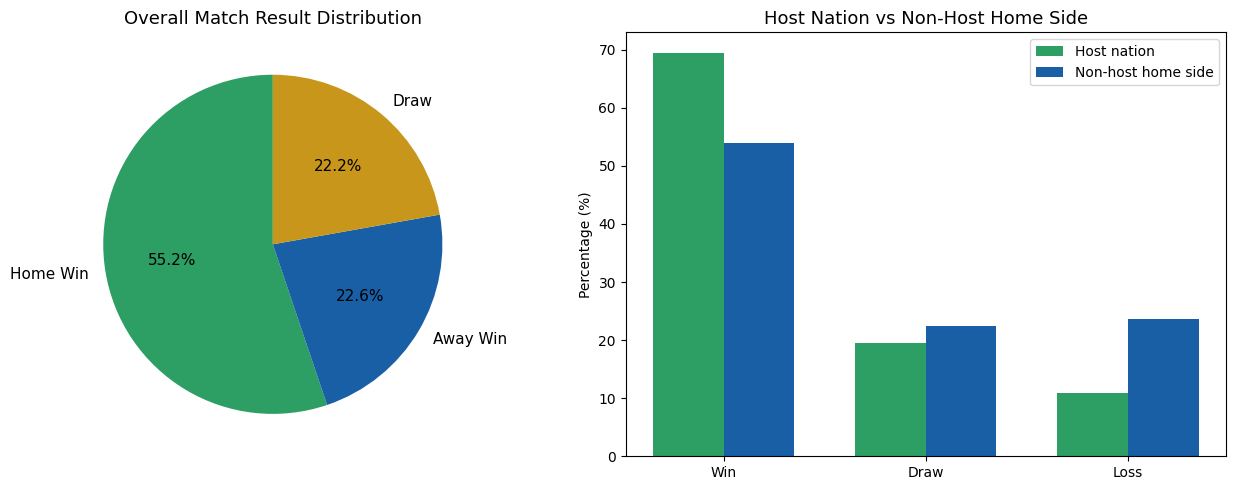

Home win %:  55.2%
Away win %:  22.6%
Draw %:      22.2%

Host nation win %:     69.5%
Non-host home win %:   53.9%


In [4]:
#Home advantage analysis
home_win_pct = (matches['result'] == 'home_win').mean() * 100
away_win_pct = (matches['result'] == 'away_win').mean() * 100
draw_pct     = (matches['result'] == 'draw').mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall result distribution
labels = ['Home Win', 'Away Win', 'Draw']
sizes  = [home_win_pct, away_win_pct, draw_pct]
colors = ['#2d9e64', '#185fa5', '#c8961a']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Overall Match Result Distribution', fontsize=13)

# Host country performance
host_matches = matches[matches['home_team'] == matches['host']].copy()
host_results = host_matches['result'].value_counts(normalize=True) * 100
non_host_home = matches[matches['home_team'] != matches['host']].copy()
non_host_results = non_host_home['result'].value_counts(normalize=True) * 100

x = np.arange(3)
w = 0.35
r = ['home_win', 'draw', 'away_win']
host_vals     = [host_results.get(r_, 0) for r_ in r]
non_host_vals = [non_host_results.get(r_, 0) for r_ in r]

axes[1].bar(x - w/2, host_vals,     w, label='Host nation',     color='#2d9e64')
axes[1].bar(x + w/2, non_host_vals, w, label='Non-host home side', color='#185fa5')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Win', 'Draw', 'Loss'])
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Host Nation vs Non-Host Home Side', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/home_advantage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Home win %:  {home_win_pct:.1f}%")
print(f"Away win %:  {away_win_pct:.1f}%")
print(f"Draw %:      {draw_pct:.1f}%")
print(f"\nHost nation win %:     {host_results.get('home_win', 0):.1f}%")
print(f"Non-host home win %:   {non_host_results.get('home_win', 0):.1f}%")

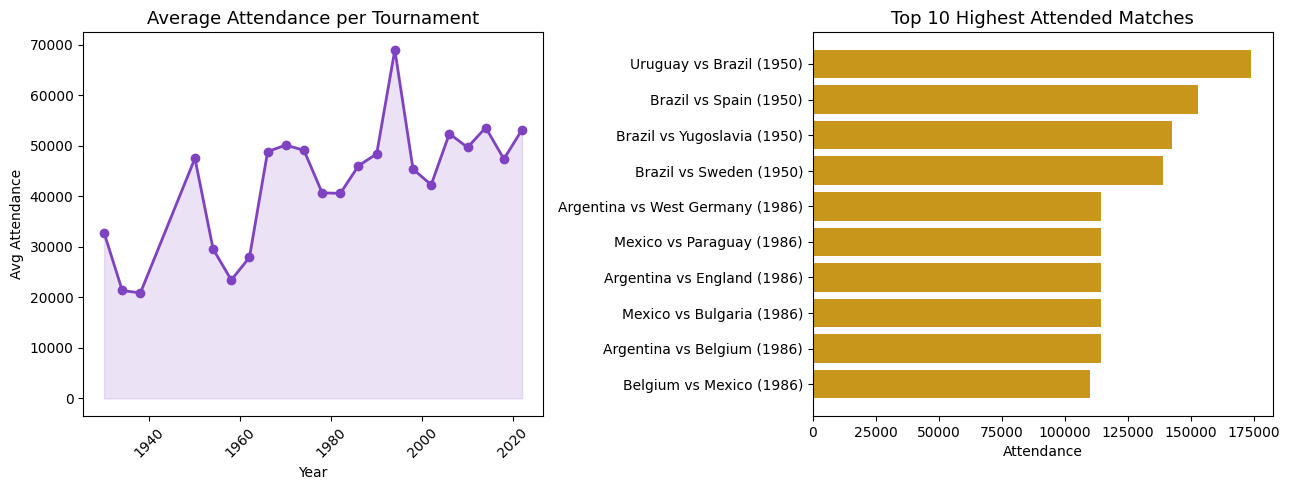

In [5]:
#Attendance Trends
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Avg attendance per tournament
att_by_year = matches.groupby('year')['attendance'].mean().reset_index()
axes[0].plot(att_by_year['year'], att_by_year['attendance'],
             marker='o', color='#7f42c0', linewidth=2)
axes[0].fill_between(att_by_year['year'], att_by_year['attendance'],
                     alpha=0.15, color='#7f42c0')
axes[0].set_title('Average Attendance per Tournament', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg Attendance')
axes[0].tick_params(axis='x', rotation=45)

# Top 10 highest attended matches
top_attended = matches.nlargest(10, 'attendance')[
    ['year', 'home_team', 'away_team', 'attendance', 'total_goals']
]
axes[1].barh(
    top_attended.apply(lambda r: f"{r['home_team']} vs {r['away_team']} ({int(r['year'])})", axis=1),
    top_attended['attendance'],
    color='#c8961a'
)
axes[1].set_xlabel('Attendance')
axes[1].set_title('Top 10 Highest Attended Matches', fontsize=13)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/processed/attendance.png', dpi=150, bbox_inches='tight')
plt.show()

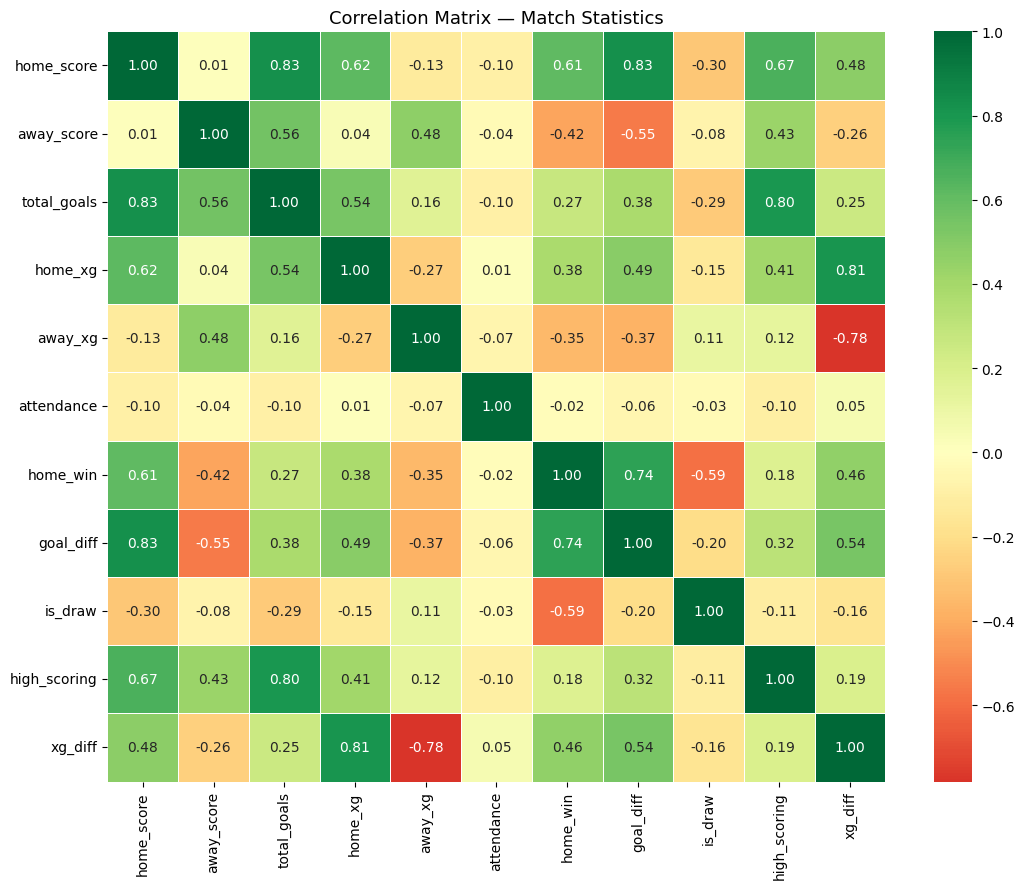

Key correlations with home_win:
home_win        1.000000
goal_diff       0.743570
home_score      0.611270
xg_diff         0.458824
home_xg         0.377933
total_goals     0.272789
high_scoring    0.176379
attendance     -0.016263
away_xg        -0.351827
away_score     -0.420295
is_draw        -0.592775


In [8]:
# Drop card columns — too many nulls, replace with better features
numeric_cols = ['home_score', 'away_score', 'total_goals',
                'home_xg', 'away_xg', 'attendance']

corr_data = matches[numeric_cols].copy()

# Force numeric
for col in numeric_cols:
    corr_data[col] = pd.to_numeric(corr_data[col], errors='coerce')

# Derived features
corr_data['home_win']       = (matches['result'] == 'home_win').astype(int)
corr_data['goal_diff']      = corr_data['home_score'] - corr_data['away_score']
corr_data['is_draw']        = (matches['result'] == 'draw').astype(int)
corr_data['high_scoring']   = (corr_data['total_goals'] >= 4).astype(int)
corr_data['xg_diff']        = corr_data['home_xg'] - corr_data['away_xg']

corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            mask=corr_matrix.isnull())
ax.set_title('Correlation Matrix — Match Statistics', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key findings
print("Key correlations with home_win:")
print(corr_matrix['home_win'].sort_values(ascending=False).to_string())